## Importing libraries and observe input folders in Kaggle notebook

In [1]:
# Linear algebra
import numpy as np

# Data processing, CSV file I/O (e.g. pd.read_csv)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
from nltk.corpus import wordnet
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
cd /content/drive/MyDrive/Machine learning 2024/Notebooks - Machine Learning/Generic Projects/Fake news classification

/content/drive/MyDrive/Machine learning 2024/Notebooks - Machine Learning/Generic Projects/Fake news classification


In [4]:
ls

 fake-news-classification.ipynb               'fake-news using n-gram_text_column.ipynb'
 fake-news-classification_text_columns.ipynb   WELFake_Dataset.csv
'fake-news using n-gram.ipynb'


### Read WELFake_Dataset.csv from kaggle/input

In [ ]:
# Select the 5000 from 0 and 5000 from 1 rows using the label columns

import pandas as pd
df = pd.read_csv('WELFake_Dataset.csv')
df_0 = df[df['label'] == 0].sample(5000)
df_1 = df[df['label'] == 1].sample(5000)
df = pd.concat([df_0, df_1])

In [ ]:
df.head()

,Unnamed: 0,title,text,label
11394,11394,New Jersey judge orders naming of Bridgegate s...,(Reuters) - A federal judge in New Jersey on T...,0
34198,34198,"Donald Trump, Hillary Clinton, Zika Virus: You...",(Want to get this briefing by email? Here’s th...,0
56198,56198,Business group pushes for U.S. flood insurance...,WASHINGTON (Reuters) - The latest attempt to o...,0
18541,18541,"Trump to give major North Korea speech, then p...",SEOUL (Reuters) - President Donald Trump will ...,0
57682,57682,Republicans have finalized compromise U.S. tax...,WASHINGTON (Reuters) - The chief tax writer in...,0


### EDA(Exploratory Data Analysis)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 11394 to 52178
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  10000 non-null  int64 
 1   title       9922 non-null   object
 2   text        9991 non-null   object
 3   label       10000 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 390.6+ KB


### Missing data analysis

In [ ]:
# Missing data analysis
df.isnull().sum()

,0
Unnamed: 0,0
title,78
text,9
label,0


In [ ]:
# Drop NA values
df = df.dropna()

# Missing data analysis again
df.isnull().sum()

,0
Unnamed: 0,0
title,0
text,0
label,0


In [ ]:
df.shape

(9913, 4)

### Drop unused columns

In [ ]:
df.drop(columns=['Unnamed: 0'],inplace=True)
df.head()

,title,text,label
11394,New Jersey judge orders naming of Bridgegate s...,(Reuters) - A federal judge in New Jersey on T...,0
34198,"Donald Trump, Hillary Clinton, Zika Virus: You...",(Want to get this briefing by email? Here’s th...,0
56198,Business group pushes for U.S. flood insurance...,WASHINGTON (Reuters) - The latest attempt to o...,0
18541,"Trump to give major North Korea speech, then p...",SEOUL (Reuters) - President Donald Trump will ...,0
57682,Republicans have finalized compromise U.S. tax...,WASHINGTON (Reuters) - The chief tax writer in...,0


### Class distribution

<Axes: ylabel='count'>

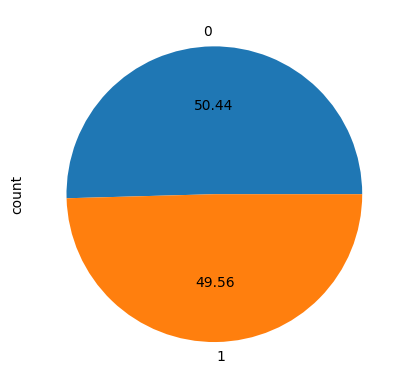

In [ ]:
# Class distribution
# 0 - Fake, 1 - Real
df['label'].value_counts().plot.pie(autopct='%.2f')

**From the graph we understand that we have balanced data.**

### Define X and y variables

In [ ]:
X = df.drop(columns=['label'])
y = df['label']

In [ ]:
messages = X.copy()

# We have to reset index as we have used dropna() earlier, otherwise it will throw an error
messages.reset_index(inplace=True)  # 0 1 2 3

### Cleaning text (Tokenization, Stemming, Lemmatization, Remove stopwords)

In [ ]:
import re
from nltk.corpus import stopwords # “the,” “and,” “is,” “in,” “for,” “where,” “when,...
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer


# Initialize the lemmatizer and stemmer
lm = WordNetLemmatizer()
ps = PorterStemmer()

# Initialize an empty list to store the cleaned messages
corpus = []

# Loop through each message in the 'messages' list
for i in range(len(messages)):
    # Remove non-alphanumeric characters from the message title using regex
    review = re.sub('[^a-zA-Z0-9]', ' ', messages['title'][i])

    # Convert the message to lowercase
    review = review.lower()

    # Split the message into individual words
    review = review.split()  # [called,the,...]

    # Lemmatize, stem each word, and remove stopwords
    review = [lm.lemmatize(x) for x in review if x not in stopwords.words('english')]   #[call, ]

    # Join the list of words back into a single string
    review = " ".join(review)

    # Append the cleaned message to the corpus list
    corpus.append(review)

In [ ]:
# Need to show corpus after lemma

corpus[0:10]

['new jersey judge order naming bridgegate scandal co conspirator',
 'donald trump hillary clinton zika virus tuesday briefing new york time',
 'business group push u flood insurance reform december deadline loom',
 'trump give major north korea speech press china',
 'republican finalized compromise u tax bill chief house tax writer',
 'u appeal higher court ruling trump revised travel ban',
 'south korea president say continue phasing nuclear power',
 'neil gorsuch helped defend disputed bush era terror policy new york time',
 'scotland see progress brexit talk london still object bill',
 'pecan step pie plate new york time']

In [ ]:
# prompt: need to sum of the number of words in the corpus

print(sum(len(sentence.split()) for sentence in corpus))

90733


In [ ]:
max_length = max(len(sentence.split()) for sentence in corpus)

print("Maximum sentence length:", max_length)

Maximum sentence length: 42


In [ ]:
len(corpus)

9913

### TF-IDF Vectorization

In [ ]:
tf = TfidfVectorizer(max_features=5000)
x=tf.fit_transform(corpus).toarray()

In [ ]:
x[0]

array([0., 0., 0., ..., 0., 0., 0.])

In [ ]:
# Iterate through the values in x[0] and print the ones that are numbers
for i, val in enumerate(x[0]):
  if val != 0:
    print(f"Index {i}: {val}")


Index 645: 0.48925663232905536
Index 919: 0.4394061129514986
Index 2375: 0.4497877792659055
Index 2418: 0.3153571672876491
Index 3062: 0.1754515555739957
Index 3180: 0.32280737285713984
Index 3930: 0.36166721991628936


In [ ]:
len(x)

9913

In [ ]:
len(x[0]) # size of columns

5000

In [ ]:
y = df["label"]
y.head()

,label
11394,0
34198,0
56198,0
18541,0
57682,0


In [ ]:
x[:5]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

### Splitting into train and test sets

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train,y_train)

RandomForestClassifier()

### Performance Metrics

In [ ]:
y_pred=rf.predict(X_test)

In [ ]:
# Classification report for rf model

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, digits=4))


              precision    recall  f1-score   support

           0     0.8753    0.8420    0.8583      1000
           1     0.8459    0.8784    0.8618       987

    accuracy                         0.8601      1987
   macro avg     0.8606    0.8602    0.8601      1987
weighted avg     0.8607    0.8601    0.8601      1987



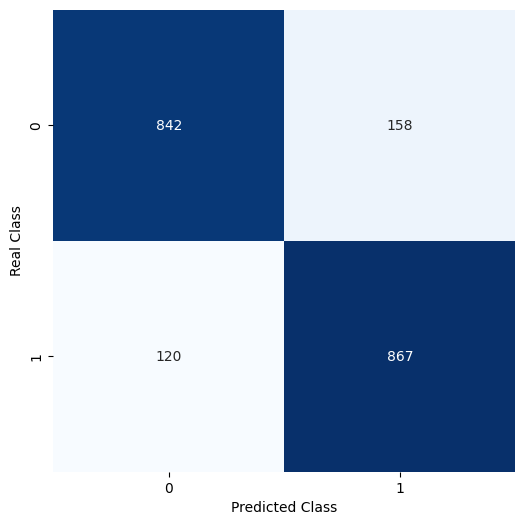

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix oluştur
cm = confusion_matrix(y_test, y_pred)

# Matrisi görselleştirme
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, square=True)
plt.xlabel('Predicted Class')
plt.ylabel('Real Class')
plt.show()

Accuracy: 0.8555611474584801
Precision: 0.8676470588235294
Recall: 0.8368794326241135
F1 Score: 0.8519855595667869

Classification Report:
               precision    recall  f1-score   support

           0     0.8444    0.8740    0.8590      1000
           1     0.8676    0.8369    0.8520       987

    accuracy                         0.8556      1987
   macro avg     0.8560    0.8554    0.8555      1987
weighted avg     0.8560    0.8556    0.8555      1987



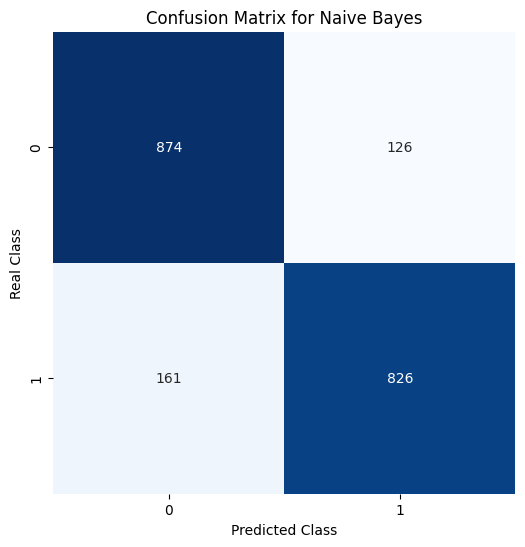

In [ ]:
# Apply Naivebayes with all results

import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Naive Bayes modelini oluştur
nb = MultinomialNB()

# Modeli eğit
nb.fit(X_train, y_train)

# Test verileri üzerinde tahmin yap
y_pred_nb = nb.predict(X_test)

# Performans metriklerini hesapla
accuracy = accuracy_score(y_test, y_pred_nb)
precision = precision_score(y_test, y_pred_nb)
recall = recall_score(y_test, y_pred_nb)
f1 = f1_score(y_test, y_pred_nb)

# Sonuçları yazdır
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Sınıflandırma raporunu yazdır
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb, digits=4))

# Confusion matrix oluştur
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Matrisi görselleştirme
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues", cbar=False, square=True)
plt.xlabel('Predicted Class')
plt.ylabel('Real Class')
plt.title('Confusion Matrix for Naive Bayes')
plt.show()


In [ ]:
# Apply all other models in one cell and also ensemble models

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from xgboost import XGBClassifier

# Initialize models
logistic_regression = LogisticRegression()
svm = SVC()
knn = KNeighborsClassifier()
decision_tree = DecisionTreeClassifier()
gradient_boosting = GradientBoostingClassifier()
adaboost = AdaBoostClassifier()
xgboost = XGBClassifier()

# Fit models
logistic_regression.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)
decision_tree.fit(X_train, y_train)
gradient_boosting.fit(X_train, y_train)
adaboost.fit(X_train, y_train)
xgboost.fit(X_train, y_train)

# Predictions
y_pred_lr = logistic_regression.predict(X_test)
y_pred_svm = svm.predict(X_test)
y_pred_knn = knn.predict(X_test)
y_pred_dt = decision_tree.predict(X_test)
y_pred_gb = gradient_boosting.predict(X_test)
y_pred_ada = adaboost.predict(X_test)
y_pred_xgb = xgboost.predict(X_test)

# Evaluate individual models
models = [logistic_regression, svm, knn, decision_tree, gradient_boosting, adaboost, xgboost]
model_names = ["Logistic Regression", "SVM", "KNN", "Decision Tree", "Gradient Boosting", "AdaBoost", "XGBoost"]

for model, name in zip(models, model_names):
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, model.predict(X_test)))
    print("Precision:", precision_score(y_test, model.predict(X_test)))
    print("Recall:", recall_score(y_test, model.predict(X_test)))
    print("F1 Score:", f1_score(y_test, model.predict(X_test)))
    print("\n")

# Ensemble model (Voting Classifier)
ensemble = VotingClassifier(estimators=[
    ('lr', logistic_regression), ('svm', svm), ('knn', knn), ('dt', decision_tree),
    ('gb', gradient_boosting), ('ada', adaboost), ('xgb', xgboost)], voting='hard')
ensemble.fit(X_train, y_train)
y_pred_ensemble = ensemble.predict(X_test)

print("--- Ensemble (Voting Classifier) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_ensemble))
print("Precision:", precision_score(y_test, y_pred_ensemble))
print("Recall:", recall_score(y_test, y_pred_ensemble))
print("F1 Score:", f1_score(y_test, y_pred_ensemble))


--- Logistic Regression ---
Accuracy: 0.8711625566180171
Precision: 0.8622398414271556
Recall: 0.8814589665653495
F1 Score: 0.8717434869739479


--- SVM ---
Accuracy: 0.8716658278812279
Precision: 0.8616600790513834
Recall: 0.8834853090172239
F1 Score: 0.8724362181090544


--- KNN ---
Accuracy: 0.5027679919476598
Precision: 0.4997465788139889
Recall: 0.9989868287740629
F1 Score: 0.6662162162162162


--- Decision Tree ---
Accuracy: 0.8112732762959235
Precision: 0.8161157024793388
Recall: 0.8004052684903749
F1 Score: 0.8081841432225064


--- Gradient Boosting ---
Accuracy: 0.8213387015601409
Precision: 0.779646017699115
Recall: 0.8926038500506586
F1 Score: 0.8323098724610297


--- AdaBoost ---
Accuracy: 0.7735279315551082
Precision: 0.7014253563390848
Recall: 0.9473150962512664
F1 Score: 0.8060344827586207


--- XGBoost ---
Accuracy: 0.8454957221942627
Precision: 0.821969696969697
Recall: 0.8794326241134752
F1 Score: 0.8497307880567792


--- Ensemble (Voting Classifier) ---
Accuracy: 0.8

In [ ]:
# Apply stacking model

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import MultinomialNB

logistic_regression = LogisticRegression()
knn = KNeighborsClassifier()
decision_tree = DecisionTreeClassifier()
logistic_regression = LogisticRegression()
svm = SVC()
knn = KNeighborsClassifier()
decision_tree = DecisionTreeClassifier()
gradient_boosting = GradientBoostingClassifier()
adaboost = AdaBoostClassifier()
xgboost = XGBClassifier()
nb = MultinomialNB()

# Define base models
base_models = [
    ('lr', logistic_regression),
    ('knn', knn),
    ('dt', decision_tree),
    ('gb', gradient_boosting),
    ('ada', adaboost),
    ('xgb', xgboost),
    ('nb',nb)
]

# Define meta-model
meta_model = LogisticRegression()

# Create stacking classifier
stacking_classifier = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model
)

# Fit the stacking classifier
stacking_classifier.fit(X_train, y_train)

# Make predictions
y_pred_stacking = stacking_classifier.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Evaluate the stacking model
print("--- Stacking Classifier ---")
print("Accuracy:", accuracy_score(y_test, y_pred_stacking))
print("Precision:", precision_score(y_test, y_pred_stacking))
print("Recall:", recall_score(y_test, y_pred_stacking))
print("F1 Score:", f1_score(y_test, y_pred_stacking))

--- Stacking Classifier ---
Accuracy: 0.8827377956718672
Precision: 0.8839103869653768
Recall: 0.8794326241134752
F1 Score: 0.8816658202133064
